# Distance Metrics, From Scratch\n\nDistance metrics decide what \"close\" means. Change the metric and you change everything downstream of it — which neighbors a KNN classifier picks, which cluster a point joins in k-means, which documents a search engine ranks as similar.\n\nThis notebook implements five metrics from scratch in numpy — no `scipy.spatial.distance`, no `sklearn` — and visualizes what makes each one different:\n\n- **Euclidean** — straight-line distance\n- **Manhattan** — grid/taxicab distance\n- **Chebyshev** — max-axis distance\n- **Minkowski** — the family that generalizes all three\n- **Cosine** — angle between vectors, ignoring magnitude\n\nThe companion interactive version of this lives at `web/` — same math, live in the browser.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dark theme to match the web companion
plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#1a1a19",
    "axes.edgecolor": "#383835",
    "axes.labelcolor": "#ffffff",
    "text.color": "#ffffff",
    "xtick.color": "#c3c2b7",
    "ytick.color": "#c3c2b7",
    "grid.color": "#2c2c2a",
    "axes.grid": True,
    "grid.linewidth": 0.5,
    "font.size": 11,
})

COLORS = {
    "euclidean": "#3987e5",
    "manhattan": "#d95926",
    "chebyshev": "#199e70",
    "minkowski": "#c98500",
    "cosine": "#9085e9",
}

## Euclidean distance

$$d(x, y) = \sqrt{\sum_i (x_i - y_i)^2}$$

The straight-line ("as the crow flies") distance. It's the one most people mean by default when they say "distance," and it's what powers ordinary KNN and k-means out of the box.

In [2]:
def euclidean_distance(x: np.ndarray, y: np.ndarray) -> float:
    diff = x - y
    return float(np.sqrt(np.sum(diff * diff)))


a = np.array([1.0, 2.0])
b = np.array([4.0, 6.0])
print("euclidean:", euclidean_distance(a, b))  # 5.0, a 3-4-5 triangle

euclidean: 5.0


## Manhattan distance

$$d(x, y) = \sum_i |x_i - y_i|$$

Distance if you can only move along the axes — like walking city blocks. No diagonal shortcuts. It's less sensitive to a single large outlier coordinate than Euclidean, because it doesn't square the differences.

In [3]:
def manhattan_distance(x: np.ndarray, y: np.ndarray) -> float:
    return float(np.sum(np.abs(x - y)))


print("manhattan:", manhattan_distance(a, b))  # |1-4| + |2-6| = 3 + 4 = 7

manhattan: 7.0


## Chebyshev distance

$$d(x, y) = \max_i |x_i - y_i|$$

Only the single worst-offending dimension counts. Useful when "close" means "every dimension is within tolerance" — e.g. a king's move distance on a chessboard, or checking if all sensor readings are within spec simultaneously.

In [4]:
def chebyshev_distance(x: np.ndarray, y: np.ndarray) -> float:
    return float(np.max(np.abs(x - y)))


print("chebyshev:", chebyshev_distance(a, b))  # max(3, 4) = 4

chebyshev: 4.0


## Minkowski distance: the family they all belong to

$$d(x, y) = \left(\sum_i |x_i - y_i|^p\right)^{1/p}$$

- $p = 1$ → Manhattan
- $p = 2$ → Euclidean
- $p \to \infty$ → Chebyshev (the max term dominates the sum as $p$ grows)

$p$ is a dial that trades off "spread the difference across all dimensions" ($p=1$) against "let the single biggest difference dominate" ($p \to \infty$).

In [5]:
def minkowski_distance(x: np.ndarray, y: np.ndarray, p: float) -> float:
    if np.isinf(p):
        return chebyshev_distance(x, y)
    return float(np.sum(np.abs(x - y) ** p) ** (1.0 / p))


for p in [1, 2, 3, 10, np.inf]:
    print(f"minkowski p={p}:", minkowski_distance(a, b, p))

# Sanity check against the dedicated implementations
assert np.isclose(minkowski_distance(a, b, 1), manhattan_distance(a, b))
assert np.isclose(minkowski_distance(a, b, 2), euclidean_distance(a, b))
assert np.isclose(minkowski_distance(a, b, np.inf), chebyshev_distance(a, b))
print("\nall consistent ✓")

minkowski p=1: 7.0
minkowski p=2: 5.0
minkowski p=3: 4.497941445275415
minkowski p=10: 4.021974149822332
minkowski p=inf: 4.0

all consistent ✓


## Cosine distance

$$\cos(\theta) = \frac{x \cdot y}{\|x\|\,\|y\|} \qquad d_{\cos}(x, y) = 1 - \cos(\theta)$$

Everything above measures how far apart two points *are*. Cosine measures how far apart they *point* — it only looks at the angle between vectors, and is blind to their length. Two vectors pointing the same direction have cosine distance 0, even if one is 100x longer. This is why it's the default for text embeddings and recommendation systems, where "magnitude" often just means "wrote more words," not "more relevant."

In [6]:
def cosine_similarity(x: np.ndarray, y: np.ndarray) -> float:
    denom = np.linalg.norm(x) * np.linalg.norm(y)
    if denom == 0:
        return 0.0
    return float(np.dot(x, y) / denom)


def cosine_distance(x: np.ndarray, y: np.ndarray) -> float:
    return 1.0 - cosine_similarity(x, y)


same_direction = np.array([2.0, 2.0])   # same direction as (1,1), different length
unit_diagonal = np.array([1.0, 1.0])
orthogonal = np.array([1.0, -1.0])

print("cosine distance, same direction:      ", cosine_distance(same_direction, unit_diagonal))
print("cosine distance, orthogonal vectors:  ", cosine_distance(unit_diagonal, orthogonal))
print("euclidean distance, same direction:   ", euclidean_distance(same_direction, unit_diagonal))

cosine distance, same direction:       2.220446049250313e-16
cosine distance, orthogonal vectors:   1.0
euclidean distance, same direction:    1.4142135623730951


## Visualizing "distance 1" — unit balls

The clearest way to see how metrics differ: plot every point that is exactly distance 1 from the origin, for each metric. The shape of that boundary *is* the metric's notion of "equally close."

For a direction (unit vector) $u$, the point on the Minkowski-$p$ unit ball in that direction is $u / \|u\|_p$ — we sample many directions and solve for the radius directly from the formula, no library calls.

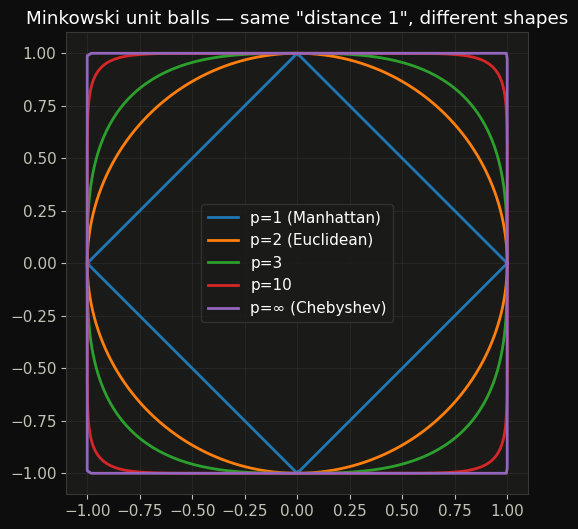

In [7]:
def minkowski_unit_ball(p: float, n_points: int = 400) -> np.ndarray:
    """Points on the boundary {x : minkowski_distance(x, 0, p) == 1}."""
    theta = np.linspace(0, 2 * np.pi, n_points)
    directions = np.stack([np.cos(theta), np.sin(theta)], axis=1)  # unit vectors (Euclidean sense)

    radii = np.empty(n_points)
    for i, d in enumerate(directions):
        p_norm = chebyshev_distance(d, np.zeros(2)) if np.isinf(p) else np.sum(np.abs(d) ** p) ** (1.0 / p)
        radii[i] = 1.0 / p_norm

    return directions * radii[:, None]


fig, ax = plt.subplots(figsize=(6, 6))
for p, label in [(1, "p=1 (Manhattan)"), (2, "p=2 (Euclidean)"), (3, "p=3"), (10, "p=10"), (np.inf, "p=∞ (Chebyshev)")]:
    ball = minkowski_unit_ball(p)
    ax.plot(ball[:, 0], ball[:, 1], label=label, linewidth=2)

ax.set_aspect("equal")
ax.set_title("Minkowski unit balls — same \"distance 1\", different shapes")
ax.legend(facecolor="#1a1a19", edgecolor="#383835", labelcolor="#ffffff")
plt.show()

## Why it matters: KNN decision boundaries change with the metric

A K-Nearest-Neighbors classifier's only real ingredient is a distance function — "classify a point by majority vote of its $k$ closest neighbors" only means something once "closest" is defined. Below is a from-scratch KNN classifier, run on the *same* synthetic dataset with three different distance metrics, so you can see the same data produce different decision boundaries.

In [8]:
rng = np.random.default_rng(7)

def make_blobs(n_per_class: int = 40) -> tuple[np.ndarray, np.ndarray]:
    class_a = rng.normal(loc=[-1.2, 0.0], scale=[1.4, 0.5], size=(n_per_class, 2))
    class_b = rng.normal(loc=[1.4, 0.3], scale=[0.6, 1.3], size=(n_per_class, 2))
    X = np.vstack([class_a, class_b])
    y = np.array([0] * n_per_class + [1] * n_per_class)
    return X, y


X_train, y_train = make_blobs()


def knn_predict(X_train, y_train, query, k, distance_fn) -> int:
    distances = np.array([distance_fn(query, x) for x in X_train])
    nearest_idx = np.argsort(distances)[:k]
    nearest_labels = y_train[nearest_idx]
    return int(np.round(nearest_labels.mean()))  # majority vote, binary labels


def decision_grid(X_train, y_train, distance_fn, k=5, resolution=60):
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xs = np.linspace(x_min, x_max, resolution)
    ys = np.linspace(y_min, y_max, resolution)
    grid = np.zeros((resolution, resolution))
    for i, yy in enumerate(ys):
        for j, xx in enumerate(xs):
            grid[i, j] = knn_predict(X_train, y_train, np.array([xx, yy]), k, distance_fn)
    return xs, ys, grid

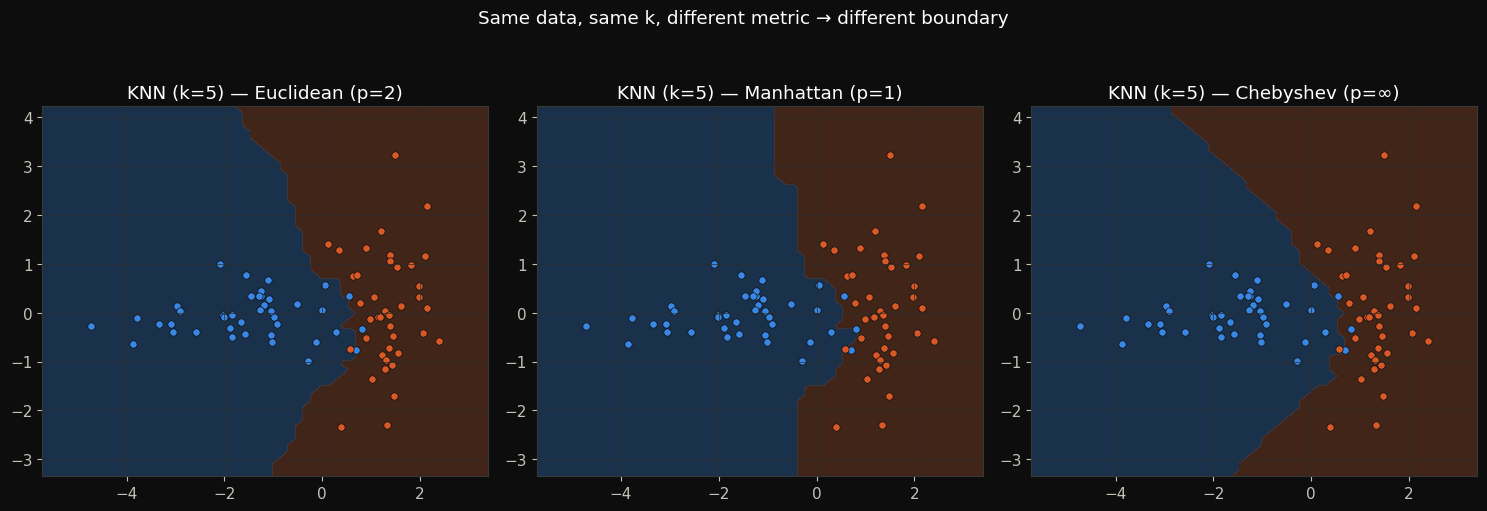

In [9]:
metrics = [
    ("Euclidean (p=2)", euclidean_distance),
    ("Manhattan (p=1)", manhattan_distance),
    ("Chebyshev (p=∞)", chebyshev_distance),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
class_colors = ["#3987e5", "#d95926"]

for ax, (name, fn) in zip(axes, metrics):
    xs, ys, grid = decision_grid(X_train, y_train, fn, k=5)
    ax.contourf(xs, ys, grid, levels=[-0.5, 0.5, 1.5], colors=["#1c5cab", "#8a3a1a"], alpha=0.35)
    for cls in (0, 1):
        pts = X_train[y_train == cls]
        ax.scatter(pts[:, 0], pts[:, 1], c=class_colors[cls], s=28, edgecolor="#0d0d0d", linewidth=0.5)
    ax.set_title(f"KNN (k=5) — {name}")
    ax.set_aspect("equal")

fig.suptitle("Same data, same k, different metric → different boundary", y=1.03)
plt.tight_layout()
plt.show()

## Takeaways

- Euclidean, Manhattan, and Chebyshev are all special cases of one Minkowski family, indexed by $p$.
- The "shape" of a metric's unit ball tells you exactly how it trades off differences across dimensions — round (Euclidean), diamond (Manhattan), square (Chebyshev).
- Cosine ignores magnitude entirely and only compares direction — a fundamentally different question from "how far apart are these points."
- The metric is not a minor implementation detail: identical data and identical $k$ produce different KNN decision boundaries depending only on which distance function is used.